In [ ]:
import os
import pathlib
import time
import datetime
import imageio
from glob import glob

import tensorflow as tf
import numpy as np 
import tensorflow.keras.backend as K
from tensorflow.image import ssim
import tensorflow_addons as tfa

from matplotlib import pyplot as plt
from IPython import display
from termcolor import colored
from IPython.display import Image
import PIL
from PIL import ImageDraw
from IPython import display

In [2]:
def set_seed(seed):
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'

class CFG:
    IMG_HEIGHT = 256
    IMG_WIDTH = 256
    BATCH_SIZE = 1       
    BUFFER_SIZE = 200
    LAMBDA = 10
    LR = 0.0002
    SEED = 7

set_seed(CFG.SEED)

In [3]:
try:
    tf.keras.mixed_precision.set_global_policy("float32")
    USE_MIXED = True
    print("Mixed precision enabled")
except Exception:
    USE_MIXED = False
    print("Mixed precision NOT enabled (fallback)")

gpus = tf.config.list_physical_devices("GPU")
if gpus:
    for g in gpus:
        try:
            tf.config.experimental.set_memory_growth(g, True)
        except Exception:
            pass

Mixed precision enabled


In [4]:
def load_and_preprocess(path):
    img = tf.io.read_file(path)
    img = tf.io.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (CFG.IMG_HEIGHT, CFG.IMG_WIDTH))
    img = (tf.cast(img, tf.float32) / 127.5) - 1.0
    return img

def make_dataset(path):
    files = glob(path + "/*.jpg")
    ds = tf.data.Dataset.from_tensor_slices(files)
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.shuffle(CFG.BUFFER_SIZE).repeat()
    ds = ds.batch(CFG.BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

day_dir = r"C:\DATA SEKUNDER\Resized 256 x 256\Day"
night_dir = r"C:\DATA SEKUNDER\Resized 256 x 256\Night"

Day = make_dataset(day_dir)
Night = make_dataset(night_dir)

Train = tf.data.Dataset.zip((Day, Night))

In [5]:
def show_sample(dataset, idx=0, title=None):
    batch = next(iter(dataset))
    img = batch[idx]
    img = tf.cast(img, tf.float32)
    img = (img * 0.5) + 0.5
    plt.figure(figsize=(8,8))
    plt.imshow(img.numpy())
    if title:
        plt.title(title)
    plt.axis('off')
    plt.show()

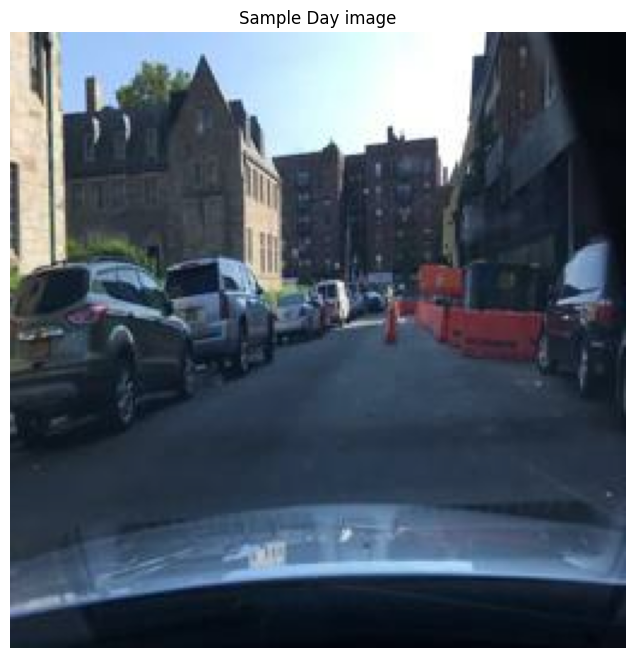

In [6]:
show_sample(Day, title='Sample Day image')

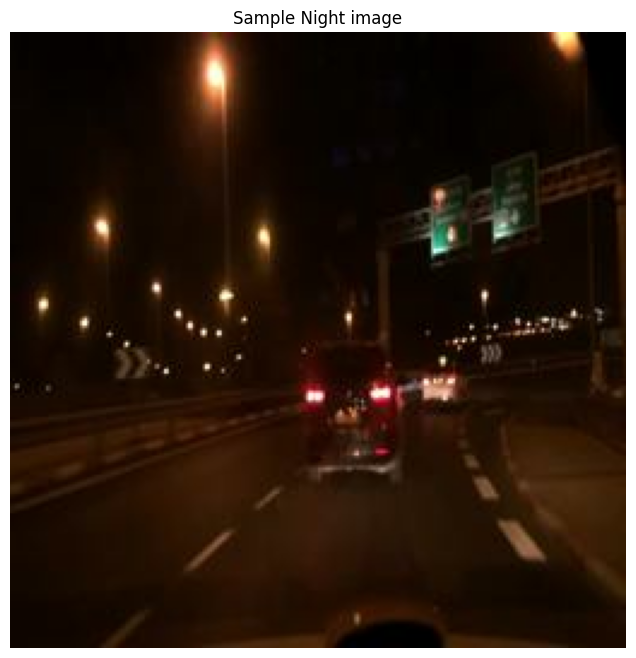

In [7]:
show_sample(Night, title='Sample Night image')

In [8]:
initializer = tf.random_normal_initializer(0, 0.02)

def resblock(x, filters):
    y = tf.keras.layers.Conv2D(filters, 3, padding="same",kernel_initializer=initializer, use_bias=False)(x)
    y = tfa.layers.InstanceNormalization()(y)
    y = tf.keras.layers.ReLU()(y)
    y = tf.keras.layers.Conv2D(filters, 3, padding="same",kernel_initializer=initializer, use_bias=False)(y)
    y = tfa.layers.InstanceNormalization()(y)
    return tf.keras.layers.Add()([y, x])

In [ ]:
def build_generator():
    inputs = tf.keras.Input((CFG.IMG_HEIGHT, CFG.IMG_WIDTH, 3))

    # ---------------- Encoder ----------------
    # Level 1
    x1 = tf.keras.layers.Conv2D(32, 7, padding="same",kernel_initializer=initializer, use_bias=False)(inputs)
    x1 = tfa.layers.InstanceNormalization()(x1)
    x1 = tf.keras.layers.ReLU()(x1)

    # Level 2
    x2 = tf.keras.layers.Conv2D(64, 3, strides=2, padding="same",kernel_initializer=initializer, use_bias=False)(x1)
    x2 = tfa.layers.InstanceNormalization()(x2)
    x2 = tf.keras.layers.ReLU()(x2)

    # Level 3 (bottleneck, lowest resolution)
    x3 = tf.keras.layers.Conv2D(128, 3, strides=2, padding="same",kernel_initializer=initializer, use_bias=False)(x2)
    x3 = tfa.layers.InstanceNormalization()(x3)
    x3 = tf.keras.layers.ReLU()(x3)

    # ---------------- Bottleneck ----------------
    b = resblock(x3, 128)
    b = resblock(b, 128)

    # ---------------- Decoder + SKIP CONNECTIONS ----------------
    # Up 1
    u1 = tf.keras.layers.Conv2DTranspose(64, 3, strides=2, padding="same",kernel_initializer=initializer, use_bias=False)(b)
    u1 = tfa.layers.InstanceNormalization()(u1)
    u1 = tf.keras.layers.ReLU()(u1)

    # Skip dengan x2
    u1 = tf.keras.layers.Concatenate()([u1, x2])

    # Up 2
    u2 = tf.keras.layers.Conv2DTranspose(32, 3, strides=2, padding="same",kernel_initializer=initializer, use_bias=False)(u1)
    u2 = tfa.layers.InstanceNormalization()(u2)
    u2 = tf.keras.layers.ReLU()(u2)

    # Skip dengan x1
    u2 = tf.keras.layers.Concatenate()([u2, x1])

    # Output
    out = tf.keras.layers.Conv2D(3, 7, padding="same",activation="tanh",kernel_initializer=initializer)(u2)

    return tf.keras.Model(inputs, out)


In [ ]:
def build_discriminator():
    inp = tf.keras.Input((CFG.IMG_HEIGHT, CFG.IMG_WIDTH, 3))

    x = tf.keras.layers.Conv2D(64, 4, strides=2, padding="same",kernel_initializer=initializer)(inp)
    x = tf.keras.layers.LeakyReLU(0.2)(x)

    x = tf.keras.layers.Conv2D(128, 4, strides=2, padding="same",kernel_initializer=initializer)(x)
    x = tfa.layers.InstanceNormalization()(x)
    x = tf.keras.layers.LeakyReLU(0.2)(x)

    x = tf.keras.layers.Conv2D(256, 4, strides=2, padding="same",kernel_initializer=initializer)(x)
    x = tfa.layers.InstanceNormalization()(x)
    x = tf.keras.layers.LeakyReLU(0.2)(x)

    out = tf.keras.layers.Conv2D(1, 4, padding="same",kernel_initializer=initializer)(x)
    return tf.keras.Model(inp, out)


In [11]:
bce = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def disc_loss(real, fake):
    real = tf.cast(real, tf.float32)
    fake = tf.cast(fake, tf.float32)
    return 0.5 * (bce(tf.ones_like(real), real) +bce(tf.zeros_like(fake), fake))

def gen_loss(fake):
    fake = tf.cast(fake, tf.float32)
    return bce(tf.ones_like(fake), fake)

def cycle_loss(real, cycled):
    real = tf.cast(real, tf.float32)
    cycled = tf.cast(cycled, tf.float32)
    return CFG.LAMBDA * tf.reduce_mean(tf.abs(real - cycled))

def identity_loss(real, same):
    real = tf.cast(real, tf.float32)
    same = tf.cast(same, tf.float32)
    return CFG.LAMBDA * 0.5 * tf.reduce_mean(tf.abs(real - same))

In [ ]:
class CycleGAN(tf.keras.Model):
    def __init__(self):
        super().__init__()
        self.Gd2n = build_generator()
        self.Gn2d = build_generator()
        self.Dn = build_discriminator()
        self.Dd = build_discriminator()

    def compile(self, opt):
        super().compile()
        self.opt_g = opt
        self.opt_d = opt

    def train_step(self, batch):
        day, night = batch

        with tf.GradientTape(persistent=True) as tape:
            # --- Generator forward ---
            fake_night = self.Gd2n(day)
            cycled_day = self.Gn2d(fake_night)

            fake_day = self.Gn2d(night)
            cycled_night = self.Gd2n(fake_day)

            same_day = self.Gn2d(day)
            same_night = self.Gd2n(night)

            # --- Discriminator forward ---
            disc_real_n = self.Dn(night)
            disc_fake_n = self.Dn(fake_night)

            disc_real_d = self.Dd(day)
            disc_fake_d = self.Dd(fake_day)

            # --- Generator losses ---
            gl_d2n = gen_loss(disc_fake_n)
            gl_n2d = gen_loss(disc_fake_d)

            cyc = cycle_loss(day, cycled_day) + cycle_loss(night, cycled_night)
            idn = identity_loss(day, same_day) + identity_loss(night, same_night)

            total_g = gl_d2n + gl_n2d + cyc + idn

            # --- Discriminator losses ---
            dl_n = disc_loss(disc_real_n, disc_fake_n)
            dl_d = disc_loss(disc_real_d, disc_fake_d)
            total_d = dl_n + dl_d

        # --- Backprop ---
        g_vars = self.Gd2n.trainable_variables + self.Gn2d.trainable_variables
        d_vars = self.Dn.trainable_variables + self.Dd.trainable_variables

        self.opt_g.apply_gradients(zip(tape.gradient(total_g, g_vars), g_vars))
        self.opt_d.apply_gradients(zip(tape.gradient(total_d, d_vars), d_vars))

        # ============================================================
        #                COMPUTE ACCURACY METRICS
        # ============================================================

        # Sigmoid to convert logits → probability
        real_n_prob = tf.sigmoid(disc_real_n)
        fake_n_prob = tf.sigmoid(disc_fake_n)

        real_d_prob = tf.sigmoid(disc_real_d)
        fake_d_prob = tf.sigmoid(disc_fake_d)

        # D should classify real as >0.5 (true) and fake as <0.5
        d_acc_real = 0.5 * (
            tf.reduce_mean(tf.cast(real_n_prob > 0.5, tf.float32)) +
            tf.reduce_mean(tf.cast(real_d_prob > 0.5, tf.float32))
        )
        d_acc_fake = 0.5 * (
            tf.reduce_mean(tf.cast(fake_n_prob < 0.5, tf.float32)) +
            tf.reduce_mean(tf.cast(fake_d_prob < 0.5, tf.float32))
        )
        d_acc = 0.5 * (d_acc_real + d_acc_fake)

        # G tries to fool D → wants fake to be >0.5
        g_acc_n = tf.reduce_mean(tf.cast(fake_n_prob > 0.5, tf.float32))
        g_acc_d = tf.reduce_mean(tf.cast(fake_d_prob > 0.5, tf.float32))
        g_acc = 0.5 * (g_acc_n + g_acc_d)

        return {
            "g_loss": total_g,
            "d_loss": total_d,
            "g_acc": g_acc,
            "d_acc": d_acc
        }


In [ ]:
class LossHistory(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.g_losses = []
        self.d_losses = []
        self.g_accs  = []
        self.d_accs  = []

    def on_epoch_end(self, epoch, logs=None):
        self.g_losses.append(logs.get("g_loss"))
        self.d_losses.append(logs.get("d_loss"))
        self.g_accs.append(logs.get("g_acc"))
        self.d_accs.append(logs.get("d_acc"))


In [47]:
gan = CycleGAN()
optimizer = tf.keras.optimizers.Adam(CFG.LR, beta_1=0.5)

loss_history = LossHistory()

gan.compile(optimizer)

EPOCHS = 2
steps = 250

gan.fit(Train,epochs=EPOCHS,steps_per_epoch=steps,callbacks=[loss_history])

Epoch 1/2
250/250 [==============================] - 270s 986ms/step - g_loss: 6.8522 - d_loss: 1.3063
Epoch 2/2
250/250 [==============================] - 244s 975ms/step - g_loss: 6.0069 - d_loss: 1.2521


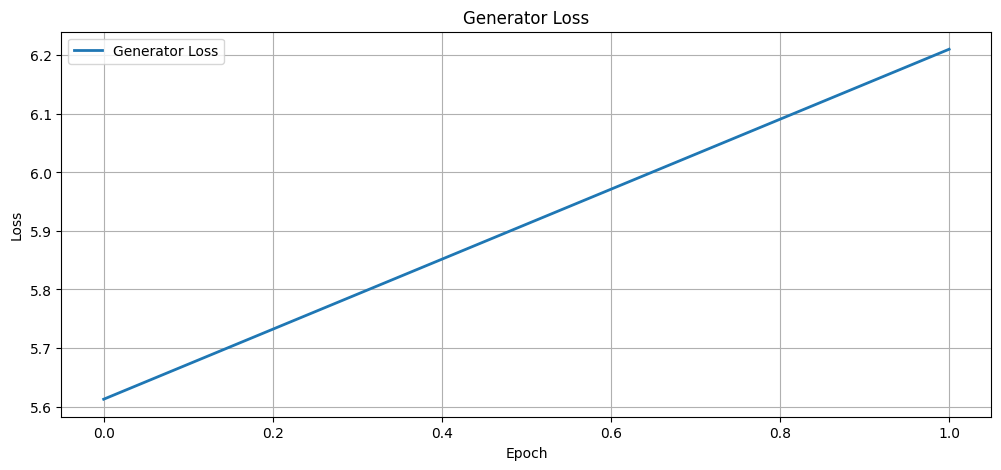

In [51]:
plt.figure(figsize=(12,5))
plt.plot(loss_history.g_losses, label="Generator Loss", linewidth=2)

plt.title("Generator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

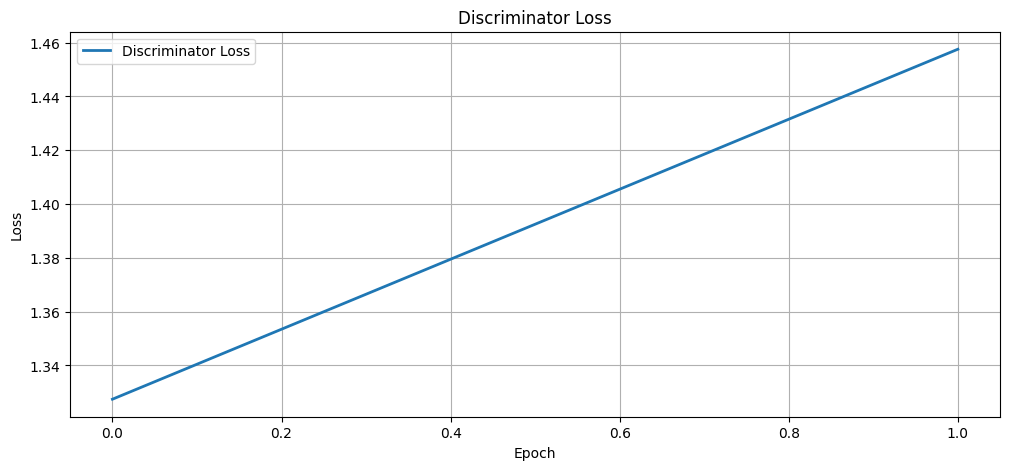

In [52]:
plt.figure(figsize=(12,5))
plt.plot(loss_history.d_losses, label="Discriminator Loss", linewidth=2)

plt.title("Discriminator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [42]:
def evaluate_ssim_5_samples(generator, dataset, num_samples=5):
    fig, axes = plt.subplots(2, num_samples, figsize=(3*num_samples, 6))
    fig.subplots_adjust(wspace=0.15, hspace=0.15)

    scores = []

    for i, real_image in enumerate(dataset.take(num_samples)):
        fake_image = generator(real_image, training=False)

        # de-normalize
        real_vis = (real_image[0] + 1) / 2.0
        fake_vis = (fake_image[0] + 1) / 2.0

        # hitung SSIM
        raw_ssim = float(ssim(real_image, fake_image, max_val=2.0).numpy()[0])
        ssim_percent = raw_ssim * 100.0
        scores.append(ssim_percent)

        # --- Row 1: Real images ---
        axes[0, i].imshow(real_vis)
        axes[0, i].set_title("Real", fontsize=12)
        axes[0, i].axis("off")

        # --- Row 2: Fake images + SSIM ---
        axes[1, i].imshow(fake_vis)
        axes[1, i].set_title(f"SSIM: {ssim_percent:.1f}%", fontsize=12)
        axes[1, i].axis("off")

    plt.show()

    print("Rata-rata SSIM:", round(np.mean(scores), 2))
    return scores

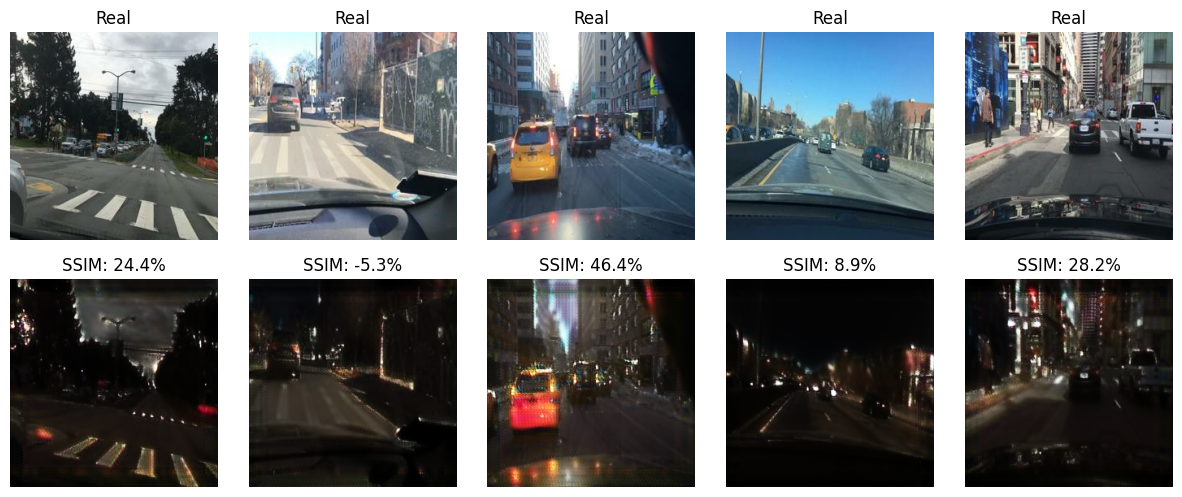

Rata-rata SSIM: 20.52


[24.436800181865692,
 -5.304550006985664,
 46.426305174827576,
 8.86550173163414,
 28.156578540802002]

In [43]:
evaluate_ssim_5_samples(gan.Gd2n, Day)

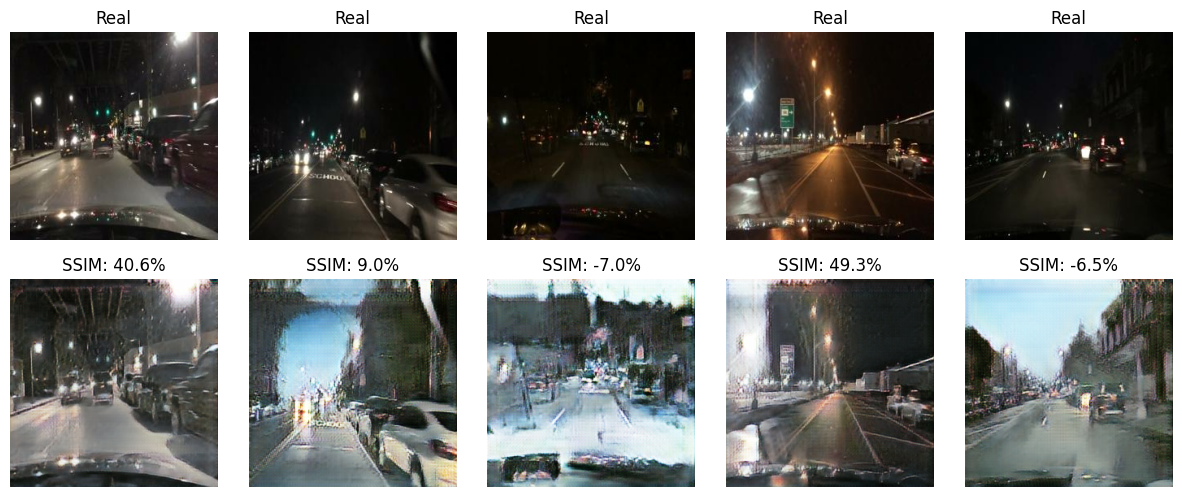

Rata-rata SSIM: 17.05


[40.61762988567352,
 8.95298719406128,
 -7.0471711456775665,
 49.30011332035065,
 -6.549914926290512]

In [44]:
evaluate_ssim_5_samples(gan.Gn2d, Night)

In [ ]:
def evaluate_fid_5_samples(generator, dataset, num_samples=5):
    from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
    import numpy as np
    from scipy.linalg import sqrtm

    # Load Inception once
    inception = InceptionV3(include_top=False, pooling='avg', input_shape=(299, 299, 3))

    # tempat display
    fig, axes = plt.subplots(2, num_samples, figsize=(3*num_samples, 6))
    fig.subplots_adjust(wspace=0.15, hspace=0.15)

    # kumpulan fitur untuk FID global
    real_feats_all = []
    fake_feats_all = []

    def prep(img):
        img = (img + 1.0) * 127.5
        img = tf.image.resize(img, (299, 299))
        img = preprocess_input(img)
        return img

    def get_feat(img):
        img = tf.expand_dims(img, 0)
        feat = inception.predict(img, verbose=0)
        return feat[0]

    for i, real_batch in enumerate(dataset.take(num_samples)):
        real_img = real_batch[0]
        fake_img = generator(tf.expand_dims(real_img, 0), training=False)[0]

        # de-normalize for display
        real_vis = (real_img + 1) / 2.0
        fake_vis = (fake_img + 1) / 2.0

        # convert for inception
        real_prep = prep(real_img)
        fake_prep = prep(fake_img)

        # extract features
        real_feat = get_feat(real_prep)
        fake_feat = get_feat(fake_prep)

        real_feats_all.append(real_feat)
        fake_feats_all.append(fake_feat)

        # "per-image FID-like distance" (bukan FID resmi)
        diff = np.sum((real_feat - fake_feat)**2)

        # --- Display real ---
        axes[0, i].imshow(real_vis)
        axes[0, i].set_title("Real")
        axes[0, i].axis("off")

        # --- Display fake ---
        axes[1, i].imshow(fake_vis)
        axes[1, i].set_title(f"DIST: {diff:.1f}")
        axes[1, i].axis("off")

    plt.show()

    # --------------------
    # Hitung FID GLOBAL
    # --------------------
    real_feats_all = np.array(real_feats_all)
    fake_feats_all = np.array(fake_feats_all)

    mu1, sigma1 = real_feats_all.mean(axis=0), np.cov(real_feats_all, rowvar=False)
    mu2, sigma2 = fake_feats_all.mean(axis=0), np.cov(fake_feats_all, rowvar=False)

    covmean = sqrtm(sigma1.dot(sigma2))
    if np.iscomplexobj(covmean):
        covmean = covmean.real

    fid_score = np.sum((mu1 - mu2)**2) + np.trace(
        sigma1 + sigma2 - 2 * covmean
    )

    print("FID (global, 5 sampel):", fid_score)
    return fid_score

In [ ]:
fid_score = evaluate_fid_5_samples(
    generator=gan.Gd2n,
    dataset=Day,
    num_samples=5
)

In [ ]:
fid_score = evaluate_fid_5_samples(
    generator=gan.Gn2d,
    dataset=Night,
    num_samples=5
)